# Io Reconstruction in the Image Plane

Method 1, updated for `amigo`'s `retrain` branch (dLux 0.15) and the `v_0.0.11` amigo files cache.

**Compatibility notes for the `retrain` branch (dLux 0.15.1):**

- `amigo`'s detector jitter parameter was renamed from `jitter` to `sigma`. `dorito`'s `ResolvedAmigoModel`/`TransformedResolvedModel` state-loading code has been updated to match (it now sets `detector.sigma` and accepts either key in the calibration state dict).
- `sgd`/`adam` moved from `zodiax.optimisation` to `amigo.fitting`.
- Everything else (`ModelFit`, `PointFit`, `Trainer`, `get_files`, plotting helpers) is unchanged, so the rest of this notebook is otherwise identical to the `v_0.0.10` version.
- If `amigo_files/v_0.0.11/calibration.npy` was produced with a dynamic (`AMIOptics(static=False)`) pupil mask, it may not contain a `transmission` key any more — `dorito` now skips setting it when that's the case, so this should just work either way.

In [1]:
# jax ecosystem
import jax
from jax import numpy as np  # apologies for this, but once you go jax you never go back

jax.config.update("jax_enable_x64", True)  # using 64-bit precision is necessary
# jax.config.update("jax_platform_name", "gpu")  # for using GPU (optional)
print(jax.local_devices()[0].device_kind)

import amigo  # for the amigo base model
import dorito  # for image reconstruction
from amigo.fitting import (
    sgd,
    adam,
)  # for gradient descent (moved from zodiax.optimisation)

# other helpful libraries
import os
from dLux import utils as dlu  # for some optics utils functionality

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

cpu


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/IO/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/IO/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.11/")
output_path = os.path.join(amigo_cache, "outputs/IO/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    # "F480M",
    "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)

sci_files = []
cal_files = []

for file in files:
    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    # if file[0].header["TARGPROP"] == "NGC1068":
    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 2236"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(cal_files, 5)
dorito.misc.truncate_files(sci_files, 18)

## Building the model

We are going to have to build the exposures. DORITO has a `ResolvedFit` class build in, however this will jointly fit all exposures from the same filter. Since we want to capture Io's rotation in a time series, we instead want to uniquely fit all five epochs. To do this, we will write a child class of `ResolvedFit` and amend the `get_key` method. By adding the `self.key` to the `log_distribution` parameter key, this ensures each exposure will fit a unique distribution.

In [4]:
class DynamicResolvedFit(dorito.model_fits.ResolvedFit):
    """
    Model fit for resolved sources where each exposure has a different
    intensity distribution.
    """

    def get_key(self, param):
        match param:
            case "log_dist":
                return "_".join([self.key, self.filter])

        return super().get_key(param)

In [5]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# just two science exposures and one calibrator for this demo
sci_exps = [dorito.model_fits.TransformedResolvedFit(file) for file in sci_files[0:1]]
# sci_exps = []
cal_exps = [amigo.model_fits.PointFit(file) for file in cal_files[0:1]]
exps = sci_exps + cal_exps

# building the model
source_size = 81  # pixels
basis, window = dorito.bases.inscribed_circ_basis(source_size)
model = dorito.models.TransformedResolvedModel(
    exposures=exps,
    optics=amigo.optical_models.AMIOptics(sparse=True),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(per_pixel_dark=True),
    # state=load_dict(cache + "final_statev44.npy"),
    state=load_dict(cache + "calibration.npy"),
    basis=basis,
    window=window,
    param_initers={"distribution": (window + 1e-8) / window.sum()},
)

/Users/mc/code/dorito/src/dorito/models.py:184: FutureWarning: 'SRF' in the state is deprecated and will be ignored in future versions; new states should not include it.
  super().__init__(exposures, optics, detector, ramp_model, read, state, param_initers)


In [6]:
best_state = load_dict(cache + "final_statev44.npy")

for param in [
    "nn_weights",
    "FF",
    "non_linearity",
    "defocus",
    "sigma",
    "transmission",
    "dark_current",
]:
    model = model.set(param, best_state[param])

File 01373_017_02_04_1
Star IO
Filter F430M
nints 100
ngroups 18



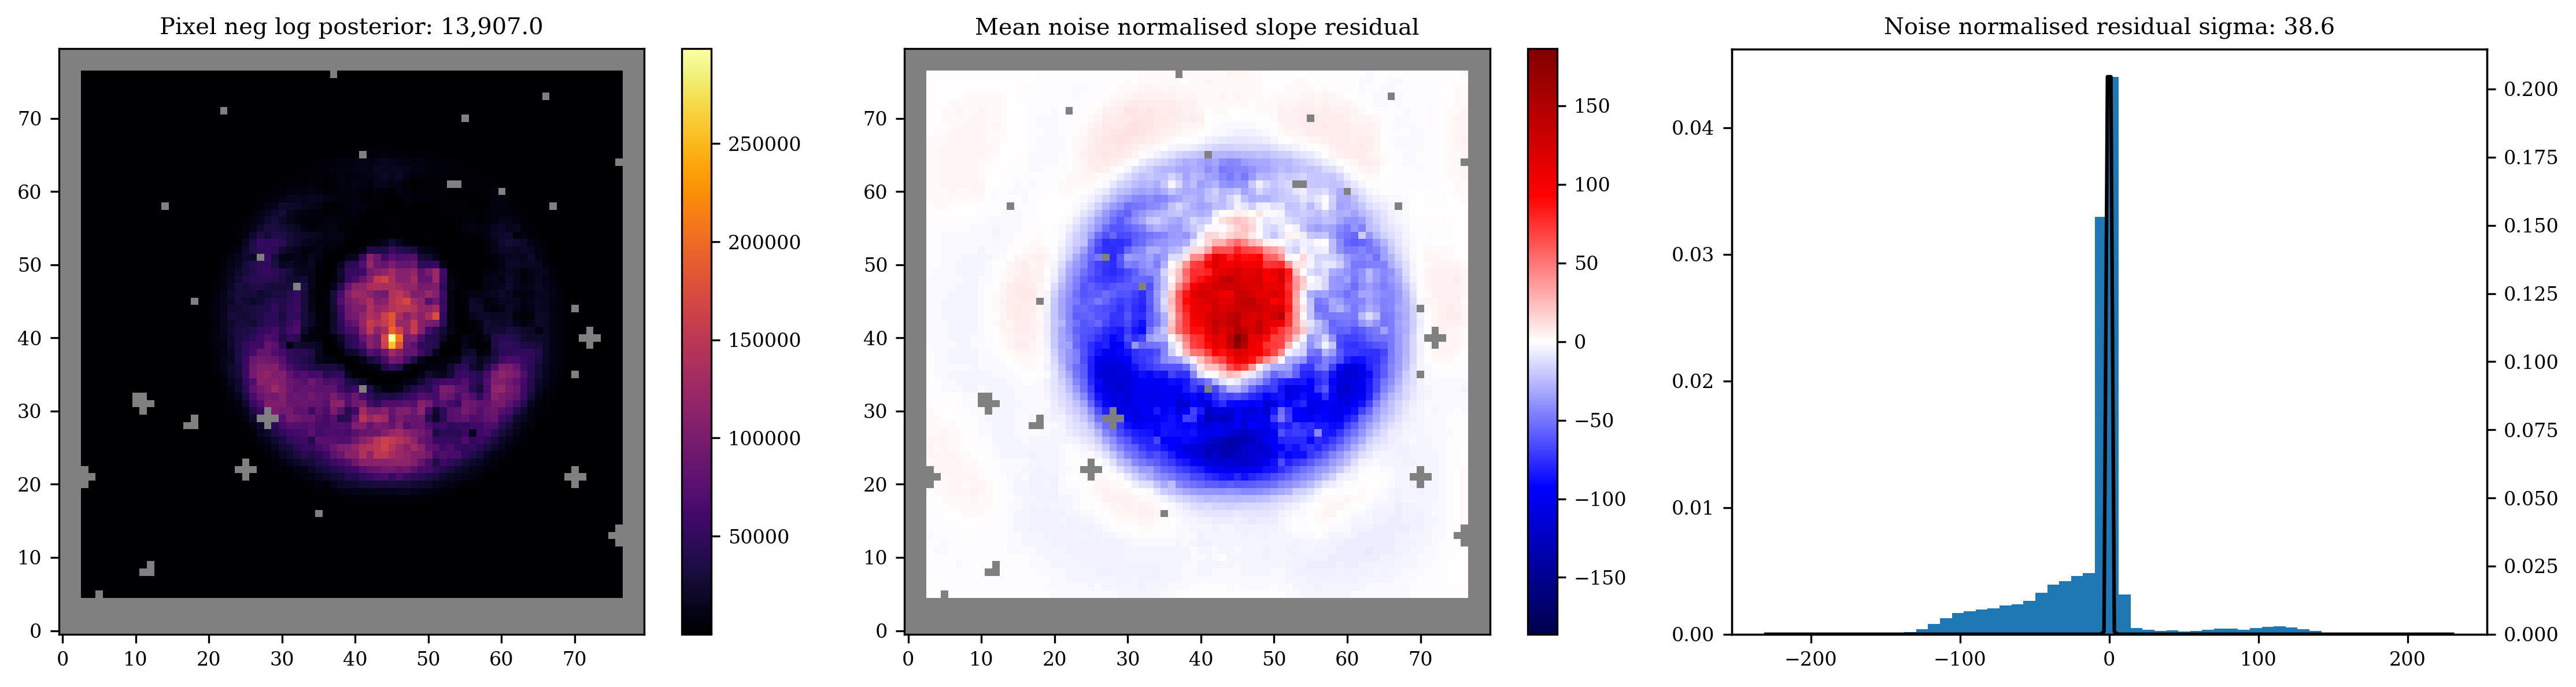

File 01373_023_02_03_1
Star HD 2236
Filter F430M
nints 8
ngroups 12



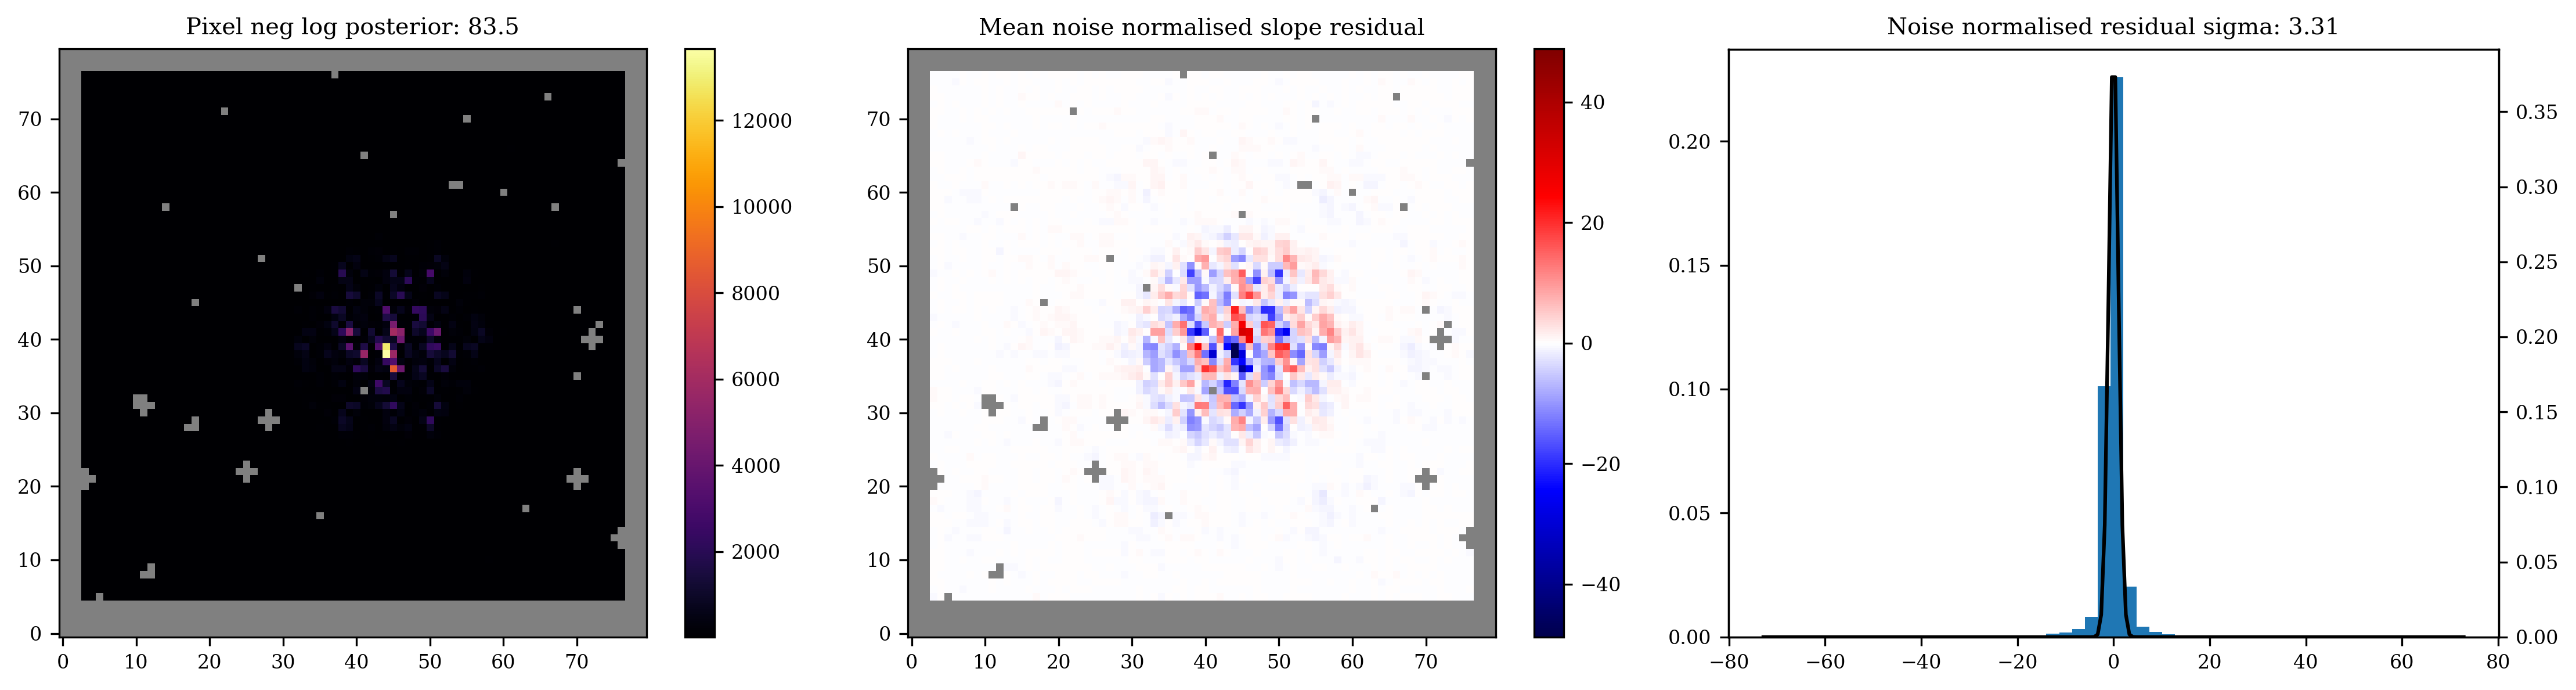

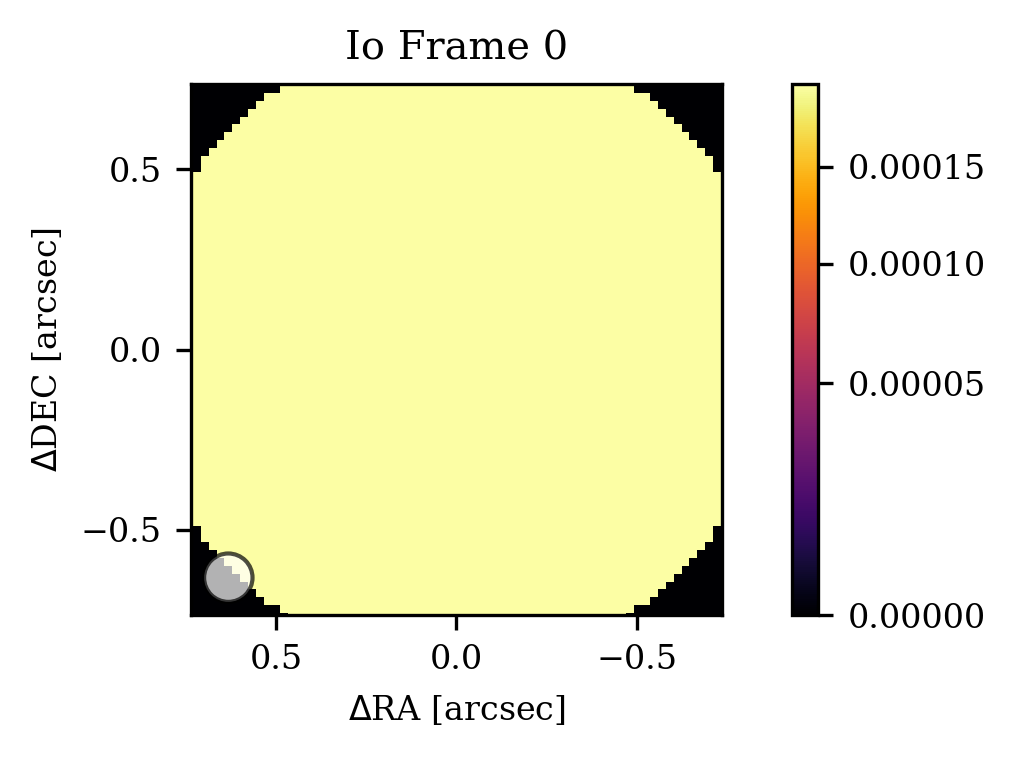

In [7]:
for exp in exps:
    exp.print_summary()
    amigo.plotting.summarise_fit(model, exp)

optics_diameter = 6.603464  # JWST aperture diameter in meters
wavel = 4.3e-6  # approximate F430M mean wavelength in meters

for idx, exp in enumerate(exps):

    # only plot science exposures
    if exp.calibrator:
        continue

    dist = model.get_distribution(exp, rotate=False)
    fig, ax = plt.subplots(figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=model.psf_pixel_scale / model.oversample,
        cmap="inferno",
        norm=mpl.colors.PowerNorm(0.6, vmin=0, vmax=None),
        diff_lim=0.5 * dlu.rad2arcsec(wavel / optics_diameter),
        scale=1.2,
    )
    fig.colorbar(c0)
    ax.set(title=f"Io Frame {idx}")
    plt.show()

## Optimisation Stage 1: Gradient Descent

In [8]:
config = {
    "positions": sgd(lr=4e-2, start=0),
    "fluxes": sgd(2e-2, 0),
    "aberrations": sgd(1e-2, 4),
    "spectra": sgd(1e-2, 10),
    "log_dist": adam(5e-3, 20),
}


def norm_fn(model_params, args):
    params = model_params.params

    # NOTE: This will not work for an arbitrary basis!
    if "log_dist" in params:
        for k, log_dist in params["log_dist"].items():
            distribution = 10**log_dist
            params["log_dist"][k] = np.log10(distribution / distribution.sum())

    if "spectra" in params:
        spectra = jax.tree.map(
            lambda x: np.clip(x, a_min=-0.8, a_max=0.8), params["spectra"]
        )
        params["spectra"] = spectra
    #
    return model_params.set("params", params), args


sci_pos_keys = []
sci_spc_keys = []
for exp in exps:
    if not exp.calibrator:
        sci_pos_keys.append(exp.map_param("positions"))
        sci_spc_keys.append(exp.map_param("spectra"))


def grad_fn(model, grads, args):
    # Nuke the position gradients for the science exposures
    if "positions" in config:
        grads = grads.multiply(sci_pos_keys, 0.0)

    # Reduce spectra gradients for the science exposures
    if "spectra" in config:
        grads = grads.multiply(sci_spc_keys, 1e-2)
    return grads, args

In [9]:
args = {"reg_dict": {"TV": (5e0, dorito.stats.TV)}}

n_epoch = 200

trainer = amigo.fitting.Trainer(
    loss_fn=dorito.stats.ramp_regularised_loss_fn,
    norm_fn=norm_fn,
    grad_fn=grad_fn,
    cache=os.path.join(amigo_cache, "fishers/"),
)

print("Populating fishers...")
trainer = trainer.populate_fishers(
    model,
    exps,
    hessians=load_dict(cache + "jacobians.npy")["hessian"],
    parameters=[p for p in config],
)

print("Number of exposures: ", len(exps))

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=exps,
    args=args,
)

Populating fishers...
KeyError: log_dist not in hessians for 01373_017_02_04_1, skipped
KeyError: log_dist not in hessians for 01373_023_02_03_1, skipped
Number of exposures:  2


  0%|          | 0/200 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 13,948.38
Estimated run time: 0:08:14
Full Time: 0:06:18
Final Loss: 580.68


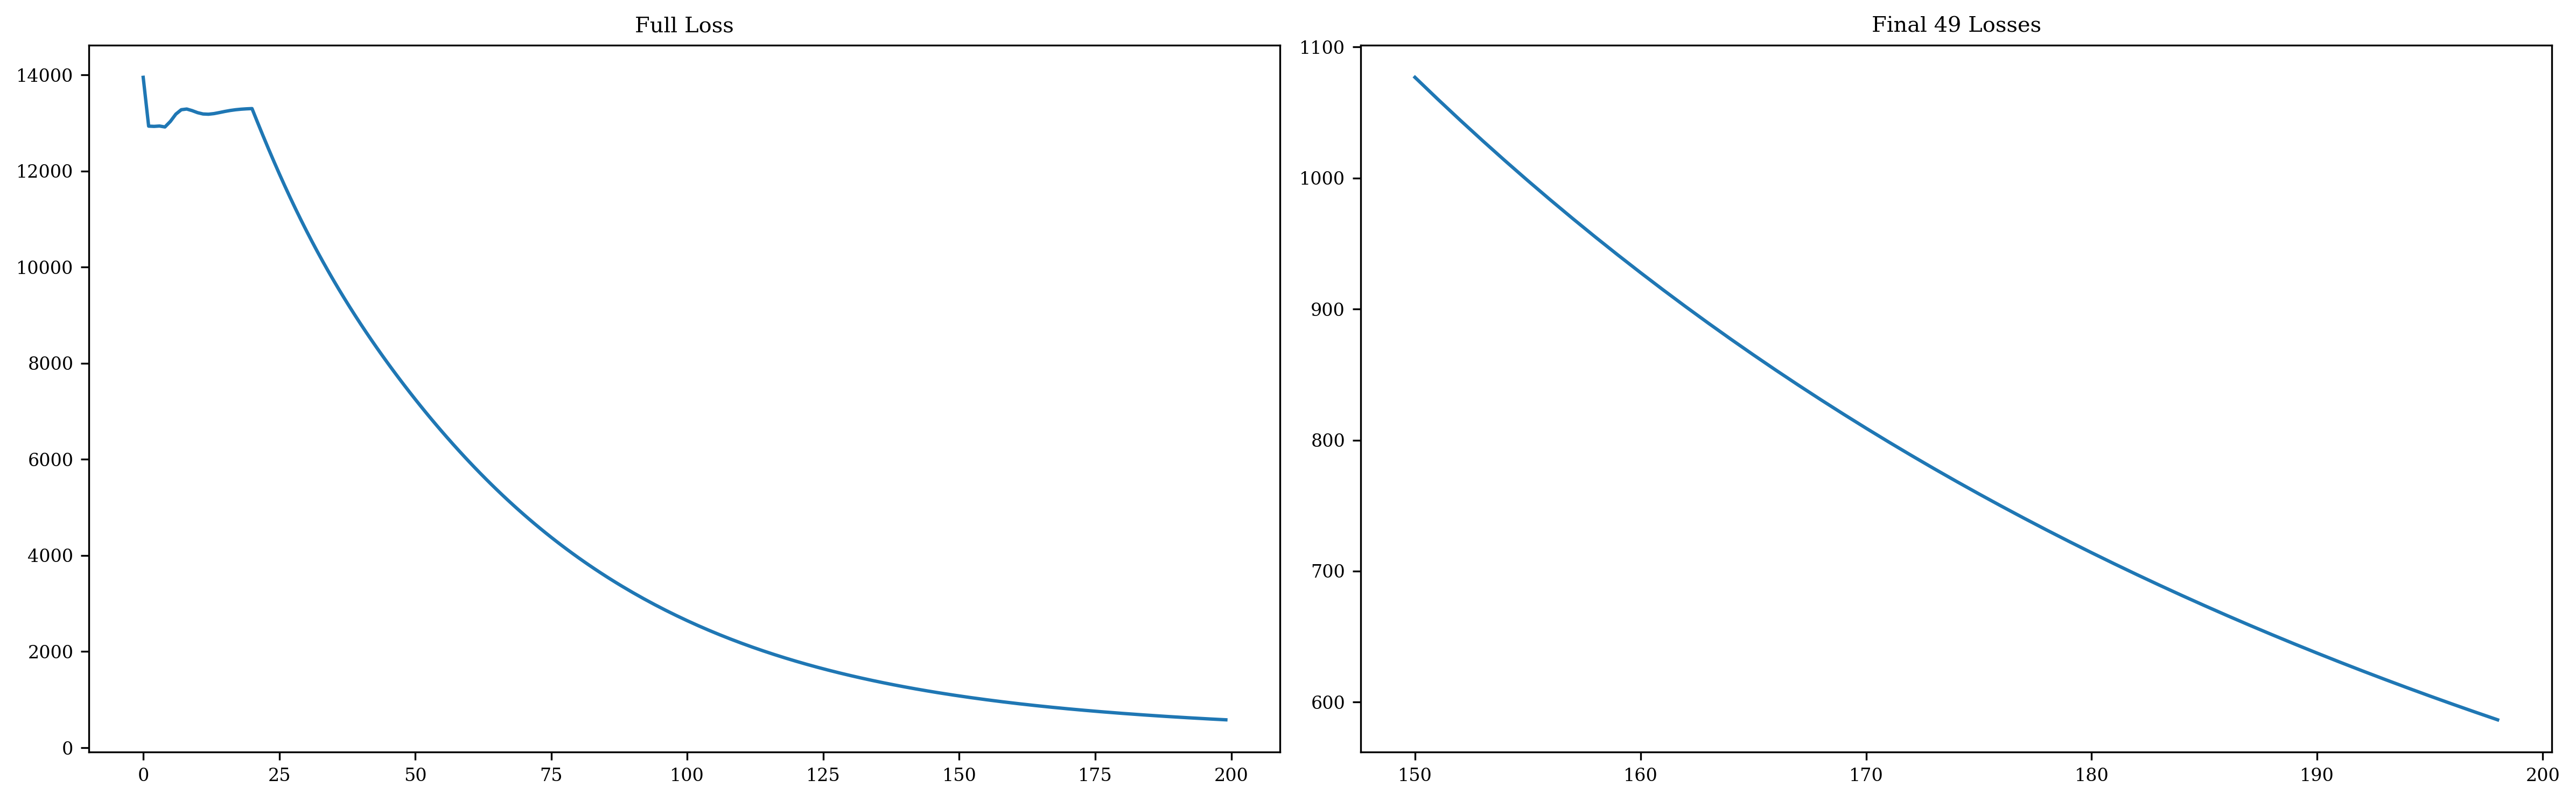

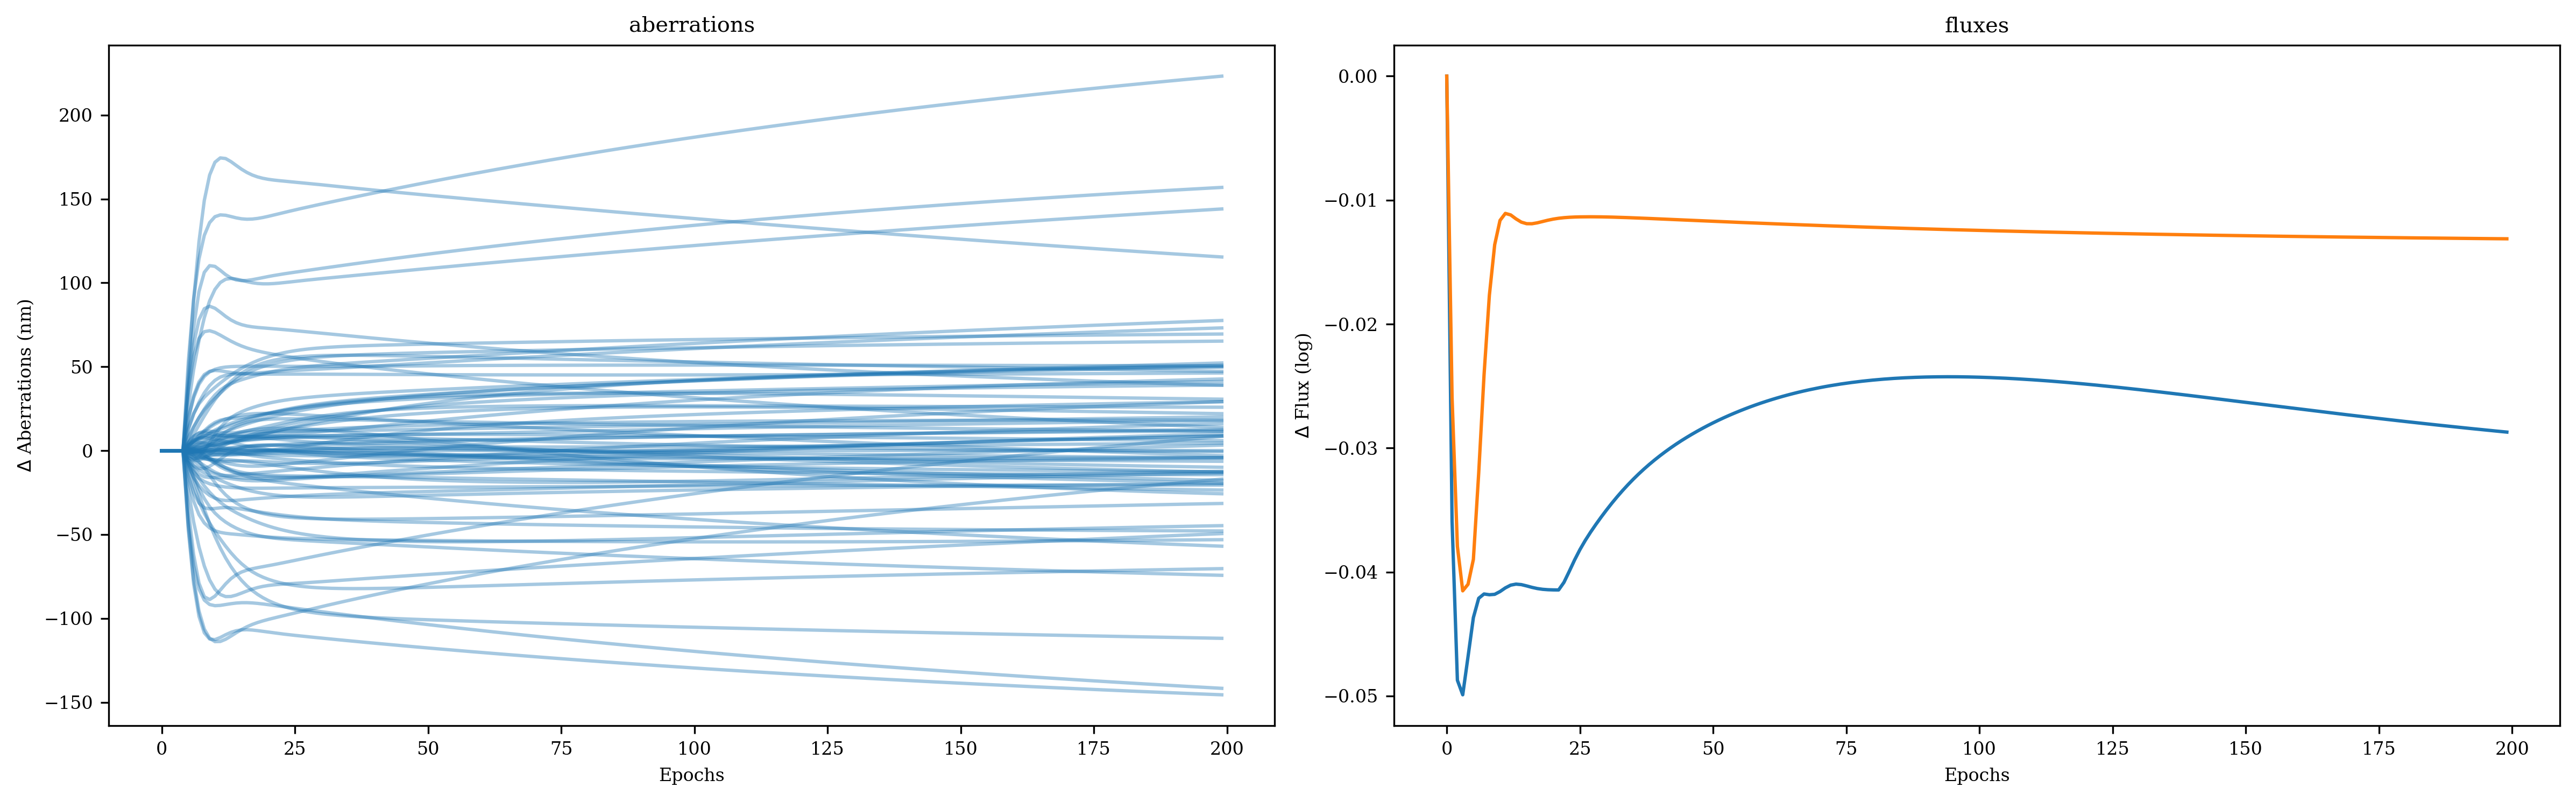

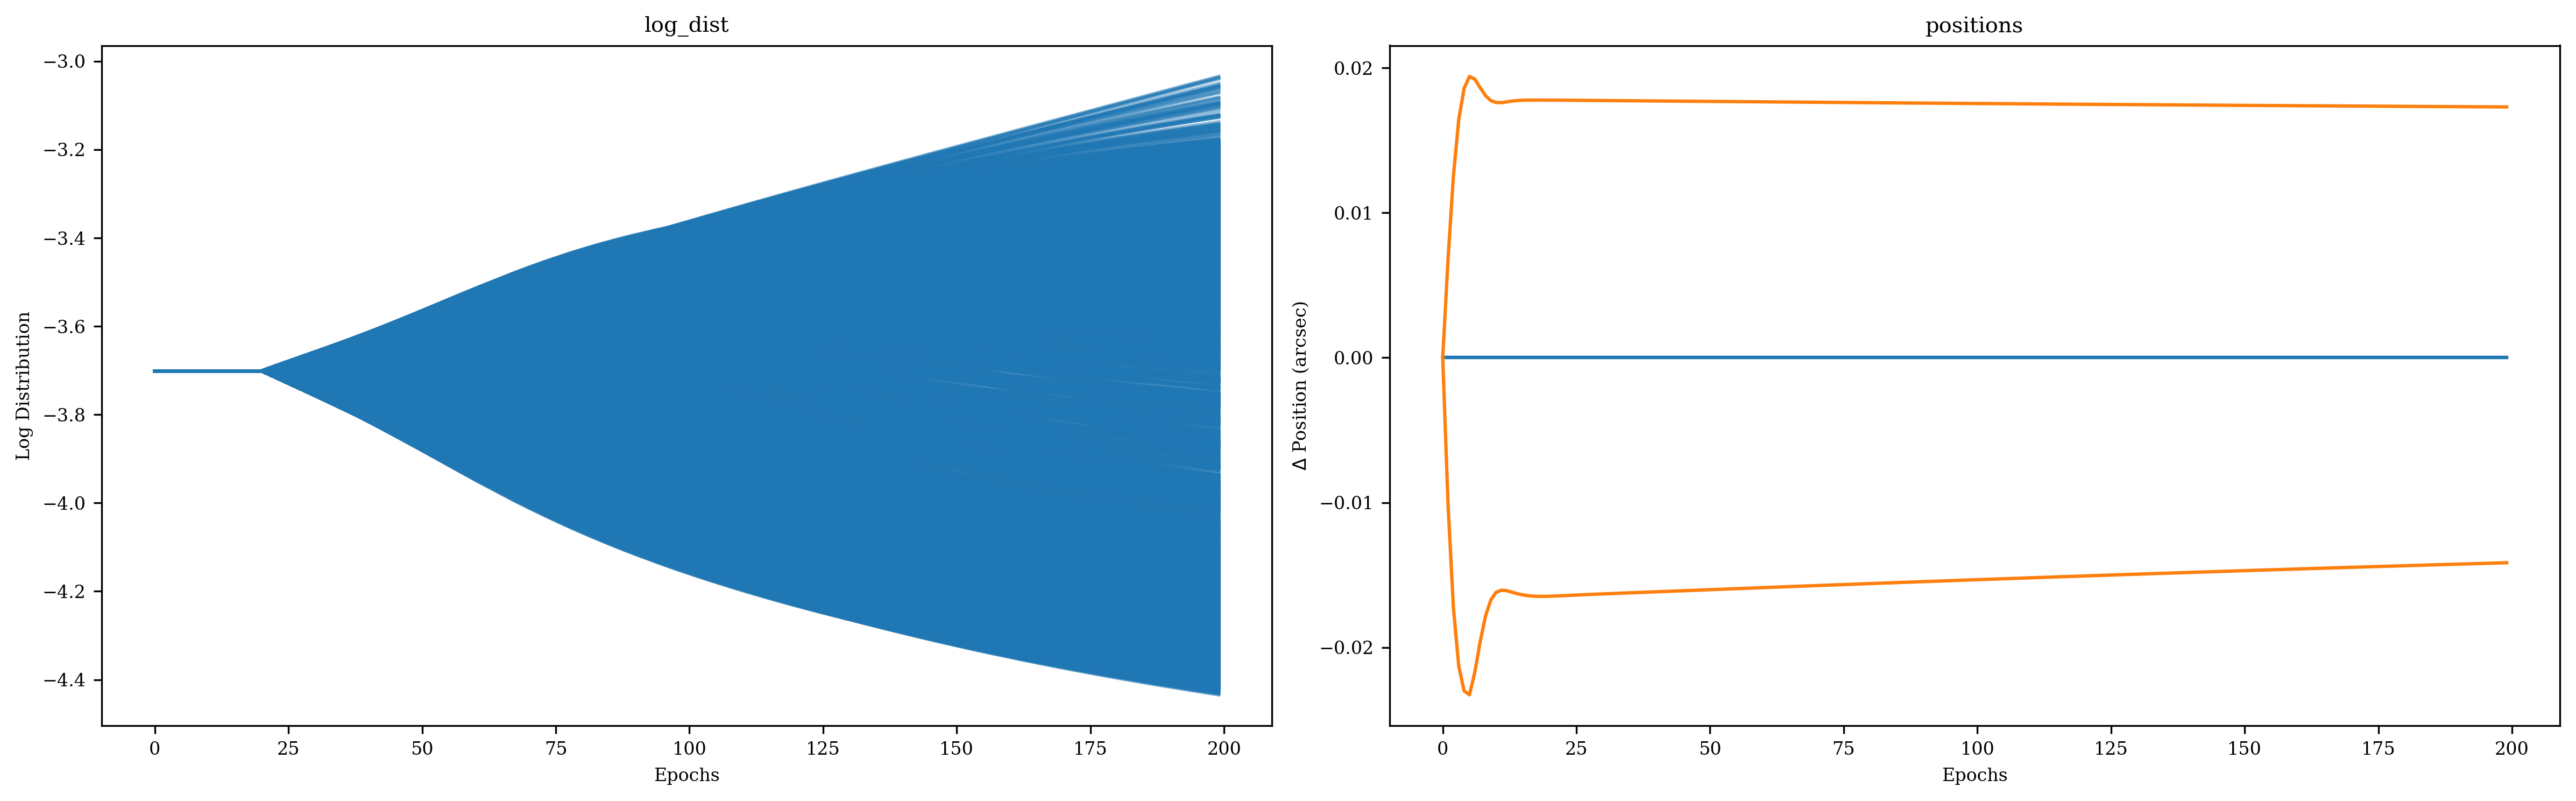

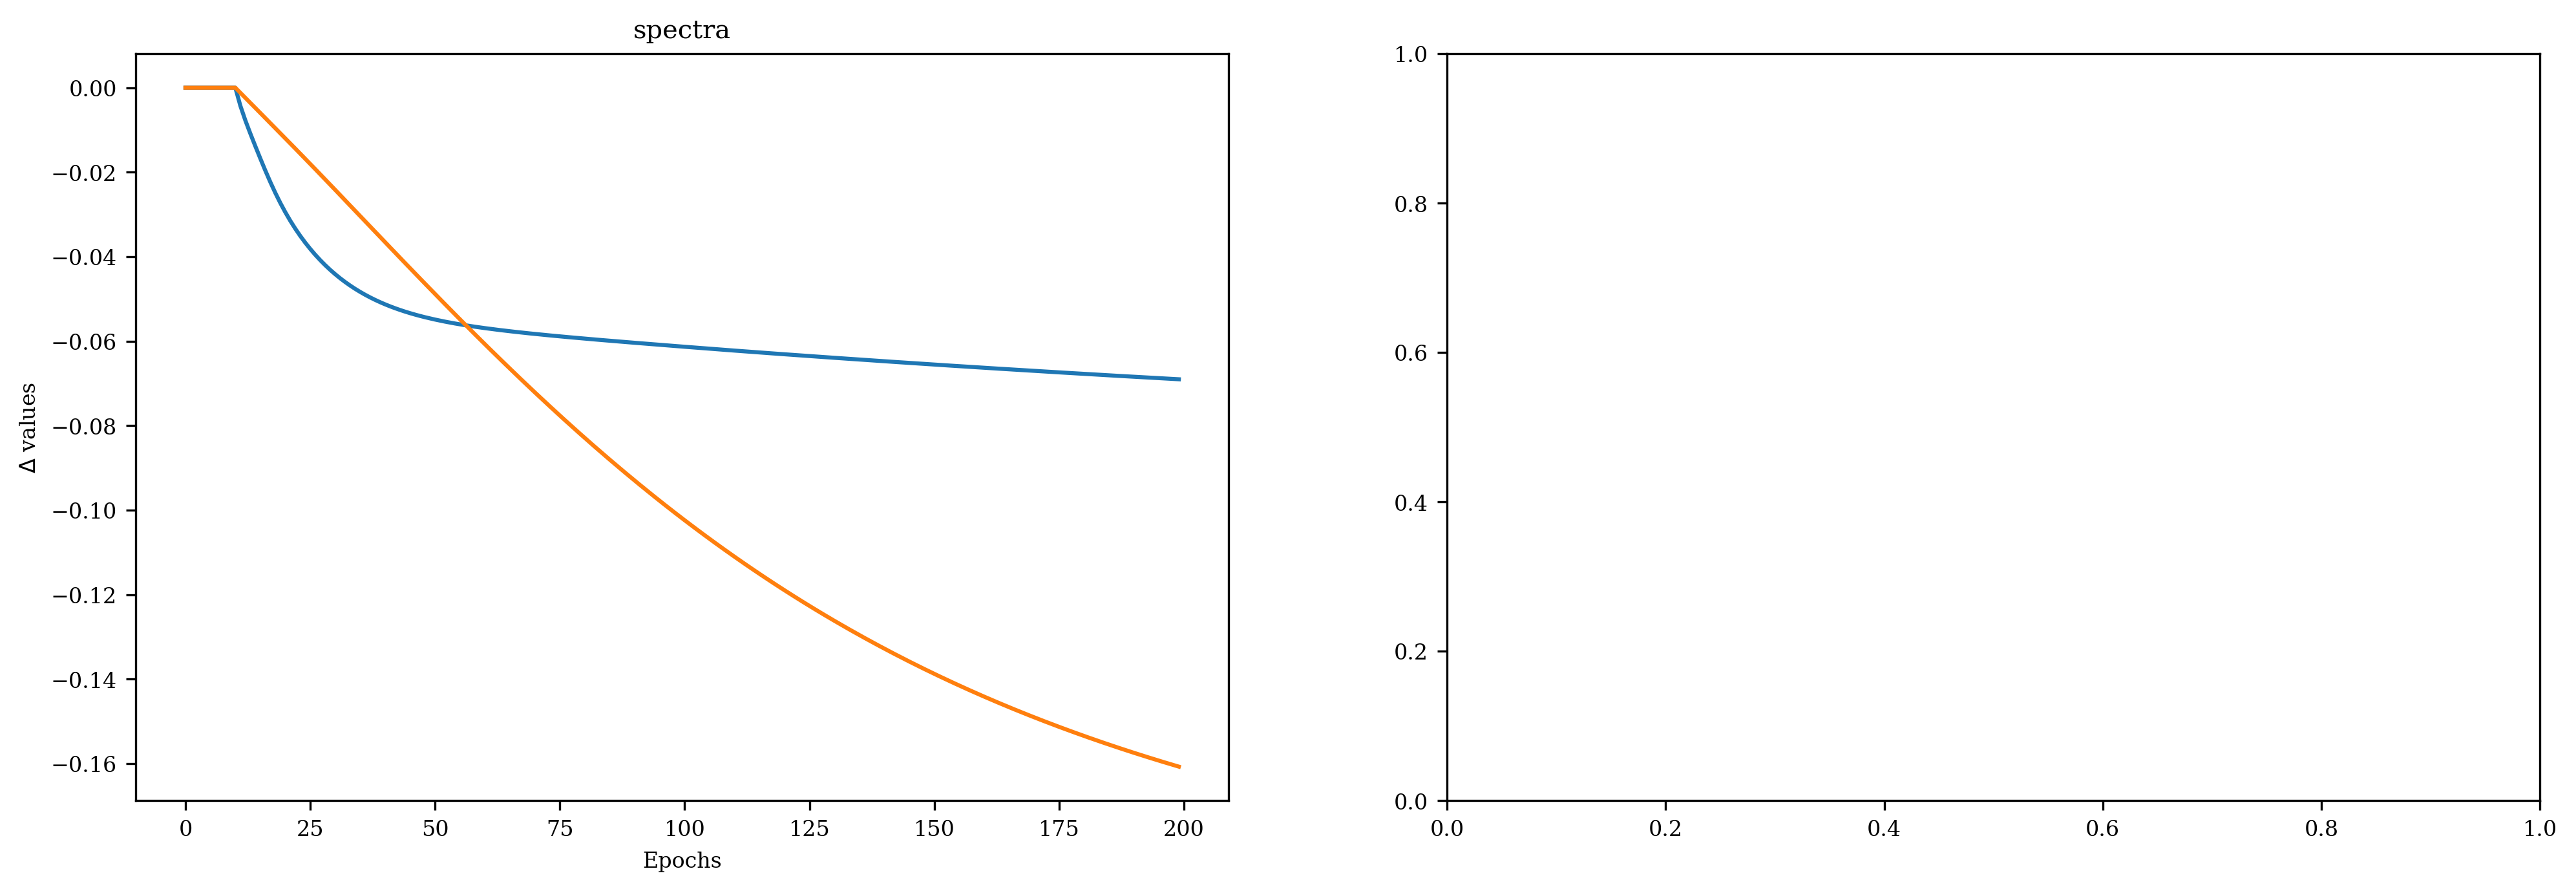

File 01373_017_02_04_1
Star IO
Filter F430M
nints 100
ngroups 18



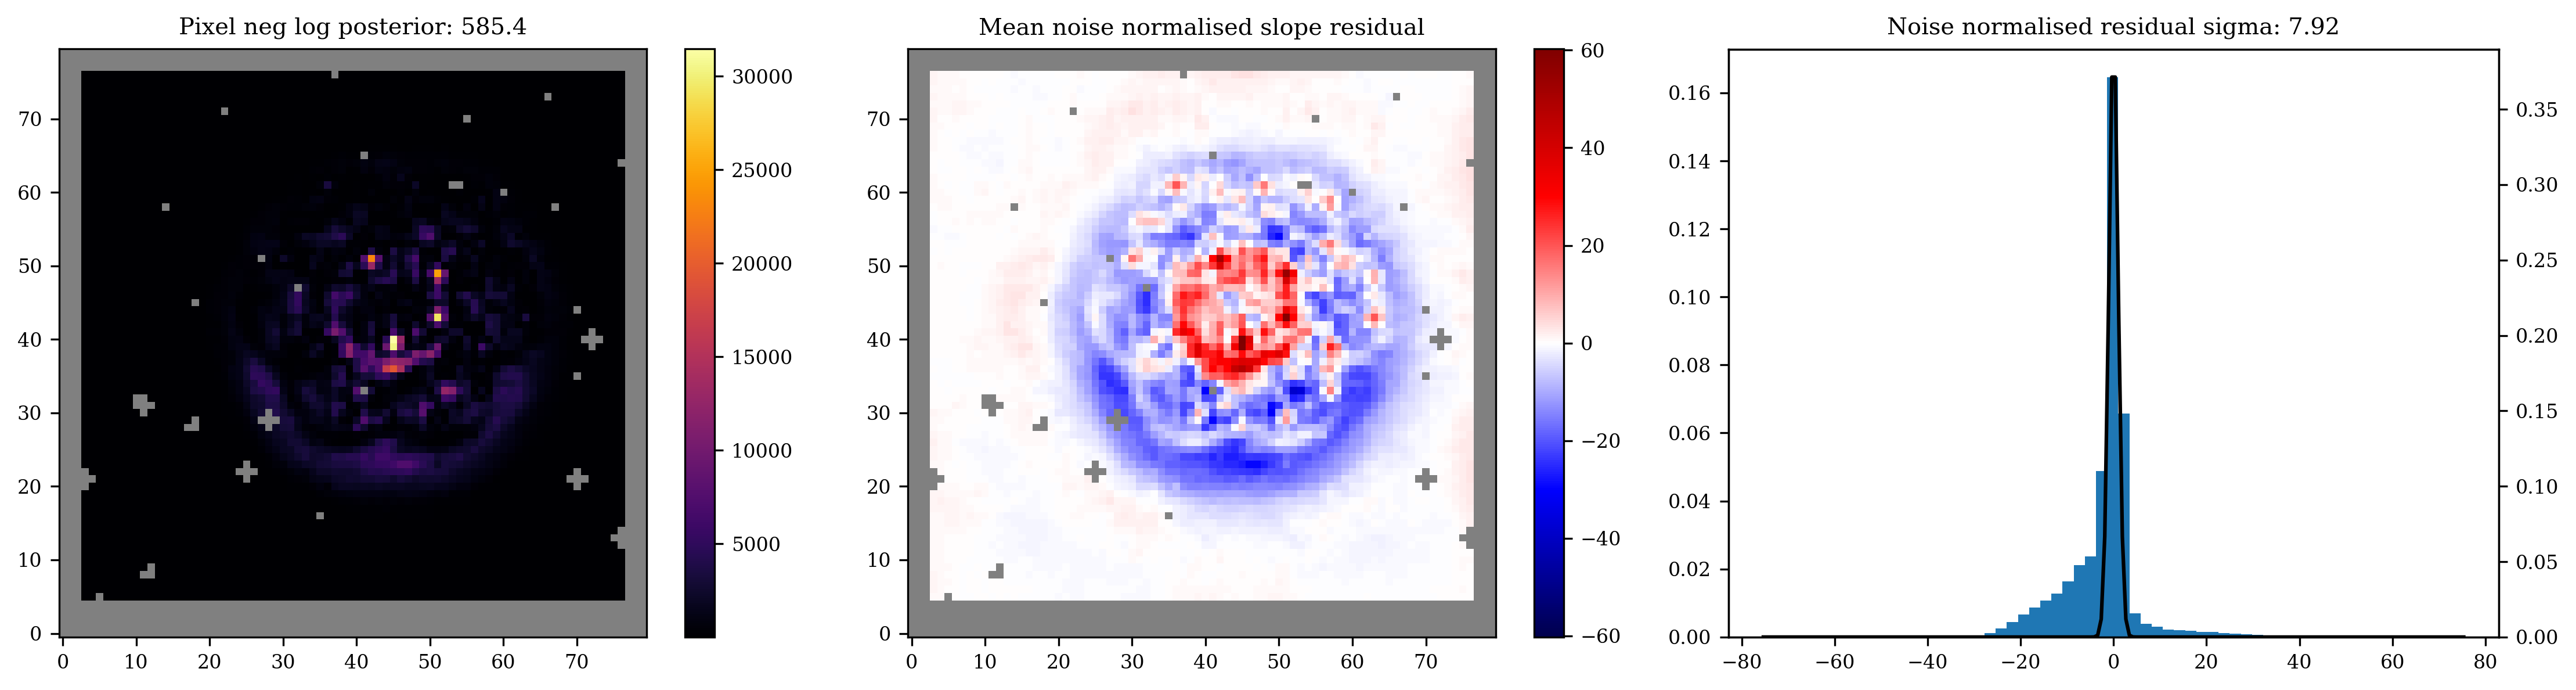

File 01373_023_02_03_1
Star HD 2236
Filter F430M
nints 8
ngroups 12



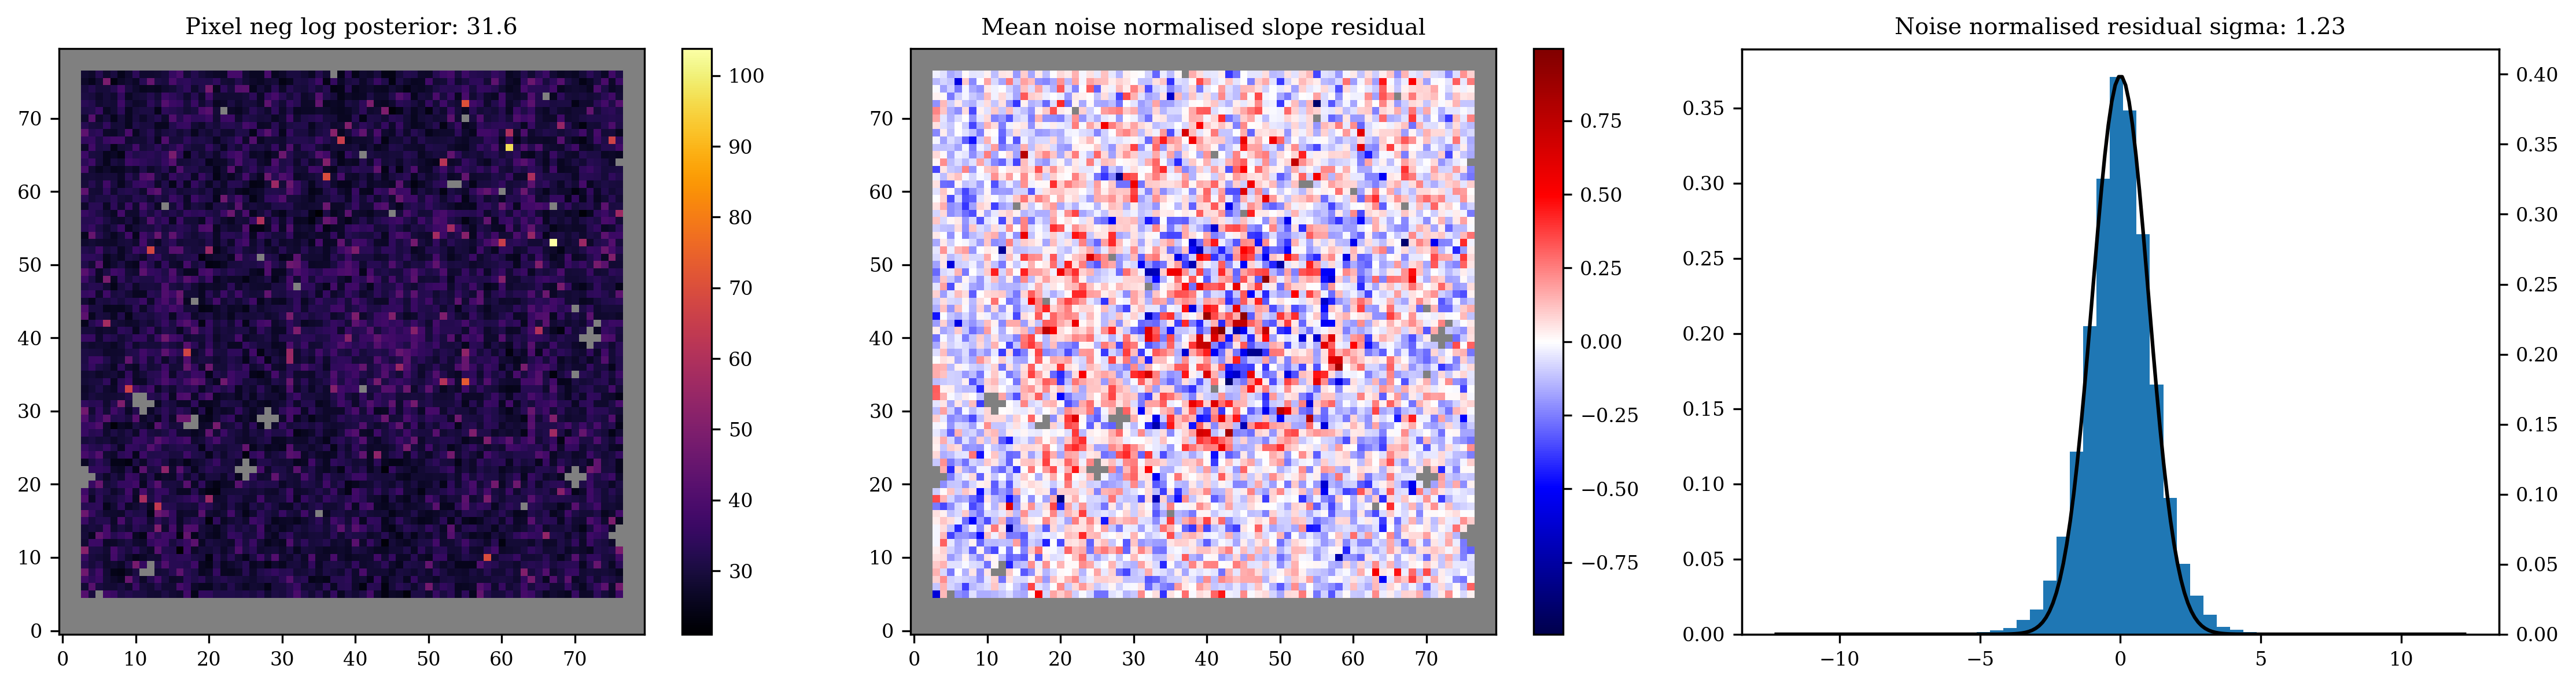

In [10]:
amigo.plotting.plot_losses(result.losses["0"], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in exps:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp)

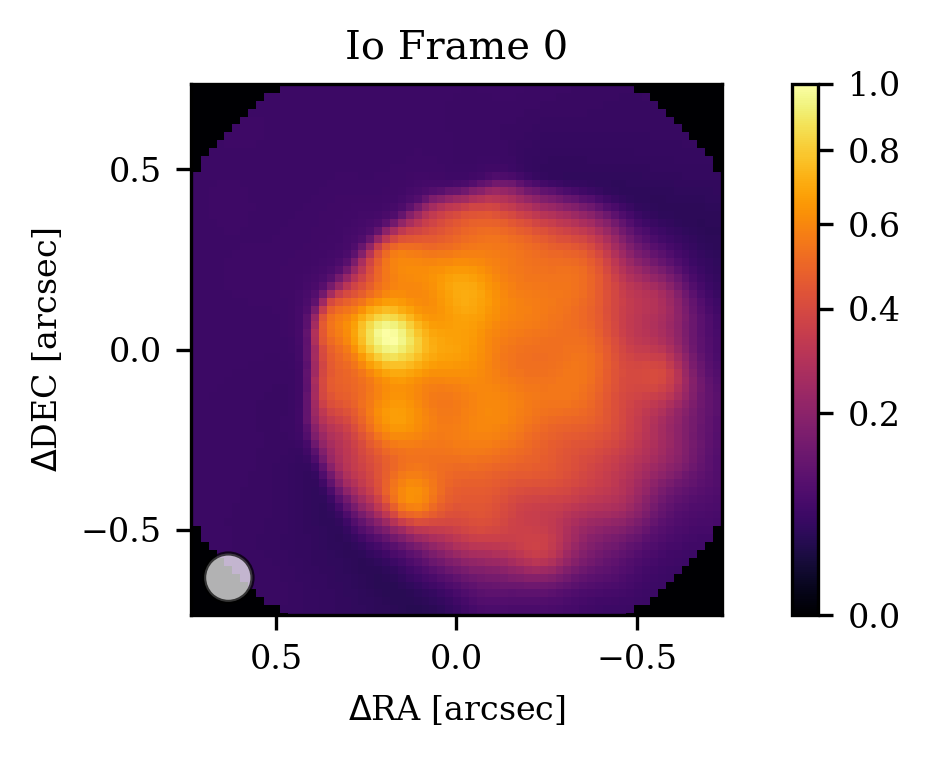

In [11]:
optics_diameter = 6.603464  # JWST aperture diameter in meters
wavel = 4.3e-6  # approximate F430M mean wavelength in meters

for idx, exp in enumerate(exps):

    # only plot science exposures
    if exp.calibrator:
        continue

    dist = result.model.get_distribution(exp, rotate=False)
    fig, ax = plt.subplots(figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist / dist.max(),
        pixel_scale=model.psf_pixel_scale / model.oversample,
        cmap="inferno",
        norm=mpl.colors.PowerNorm(0.6, vmin=0, vmax=1.0),
        diff_lim=0.5 * dlu.rad2arcsec(wavel / optics_diameter),
        scale=1.2,
    )
    fig.colorbar(c0)
    ax.set(title=f"Io Frame {idx}")
    plt.show()